Today's topics:
* `for` loops — over lists, dict items, DataFrame rows and columns
* `if` / `elif` / `else` — branching beyond a single `True`/`False`
* When to loop vs. vectorize

> HW5 Problems 1-4

# Why a loop, when Pandas already vectorizes?

*Lecture 11: `data[data['Structure'] == 'FCC']` — no loop. So what's left for `for`/`if` to do?*

1. **Iterating over things that aren't numeric data** — values one at a time, or column *names*
2. **Per-item branching with 3+ outcomes** — doesn't collapse into one mask

Looping row-by-row is *slower* than vectorized — fine at this scale, often the clearest code anyway.

**Rule:** one operation on a whole column → vectorize. Something once per item → loop.

# Load the dataset

## Dataset: Periodic Table Properties

This dataset contains basic physical and chemical properties of chemical elements
from the periodic table, including standard atomic weight, density, atomic radius,
electronegativity, melting point, and crystal structure.

Columns include: `Element`, `Standard Atomic Weight`, `Density (g/cm^3)`,
`Atomic Radius`, `Electronegativity`, `Melting Point`, `Structure`, and others.

In [1]:
import os
import pandas as pd

_file = 'periodic_table.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}', f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    data = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e
data

,Element,Standard Atomic Weight,Atomic Radius,Structure,Electronegativity,Valence,Melting Point (K),Density (g/cm^3),Heat of Fusion (kJ/mol),Molar Heat Capacity (J/mol*K),Young's Modulus (GPa),Poisson Ratio
0,Cu,63.5460,0.128 nm,FCC,1.8,2+,1357.7700,8.960,13.260,24.440,119.0,0.340
1,Ni,58.6934,0.125 nm,FCC,1.8,2+,1728.0000,8.908,17.480,26.070,200.0,0.310
2,Al,26.9810,0.143 nm,FCC,1.5,3+,933.4700,2.700,10.710,24.200,70.0,0.350
3,Zn,65.3800,0.133 nm,HCP,1.7,2+,692.6800,7.140,7.320,25.470,108.0,0.250
4,Pb,207.2000,0.175 nm,FCC,1.6,2+,600.6100,11.340,4.770,26.650,16.0,0.440
5,Sc,44.9550,0.162 nm,HCP,1.4,2+,1814.0000,2.985,14.100,25.520,74.4,0.279
6,Ti,47.8670,0.147 nm,HCP,1.5,4+,1941.0000,4.506,14.150,25.060,116.0,0.320
7,V,50.9415,0.134 nm,BCC,1.6,5+,2183.0000,6.110,21.500,24.890,128.0,0.370
8,Cr,51.9961,0.128 nm,BCC,1.7,6+,2180.0000,7.190,21.000,23.350,279.0,0.210
9,Ga,69.7230,0.135 nm,ORTHO,1.8,3+,302.9146,5.910,5.590,25.860,9.8,0.470


Same 14-element table as Lectures 9 and 11 — small enough to check a loop's output by eye.

In [2]:
data.head()

,Element,Standard Atomic Weight,Atomic Radius,Structure,Electronegativity,Valence,Melting Point (K),Density (g/cm^3),Heat of Fusion (kJ/mol),Molar Heat Capacity (J/mol*K),Young's Modulus (GPa),Poisson Ratio
0,Cu,63.5460,0.128 nm,FCC,1.8,2+,1357.77,8.960,13.26,24.44,119.0,0.34
1,Ni,58.6934,0.125 nm,FCC,1.8,2+,1728.00,8.908,17.48,26.07,200.0,0.31
2,Al,26.9810,0.143 nm,FCC,1.5,3+,933.47,2.700,10.71,24.20,70.0,0.35
3,Zn,65.3800,0.133 nm,HCP,1.7,2+,692.68,7.140,7.32,25.47,108.0,0.25
4,Pb,207.2000,0.175 nm,FCC,1.6,2+,600.61,11.340,4.77,26.65,16.0,0.44


# `for` loops: lists, dict items, DataFrame rows, DataFrame columns

*Loop over a column's values:*

In [3]:
for el in data['Element']:
    print(el)

Cu
Ni
Al
Zn
Pb
Sc
Ti
V
Cr
Ga
Sn
Co
In
Fe


Accumulator pattern (Lecture 7), driven by a Pandas column:

In [4]:
labels = []
for el in data['Element']:
    labels.append(f"{el} sample")

labels

['Cu sample',
 'Ni sample',
 'Al sample',
 'Zn sample',
 'Pb sample',
 'Sc sample',
 'Ti sample',
 'V sample',
 'Cr sample',
 'Ga sample',
 'Sn sample',
 'Co sample',
 'In sample',
 'Fe sample']

Build a dict — `zip` + `dict()` (Lecture 7):

In [5]:
density_lookup = dict(zip(data['Element'], data['Density (g/cm^3)']))
density_lookup

{'Cu': 8.96,
 'Ni': 8.908,
 'Al': 2.7,
 'Zn': 7.14,
 'Pb': 11.34,
 'Sc': 2.985,
 'Ti': 4.506,
 'V': 6.11,
 'Cr': 7.19,
 'Ga': 5.91,
 'Sn': 7.265,
 'Co': 8.9,
 'In': 7.31,
 'Fe': 7.874}

`.items()` — key and value together:

In [6]:
for el, dens in density_lookup.items():
    print(el, dens)

Cu 8.96
Ni 8.908
Al 2.7
Zn 7.14
Pb 11.34
Sc 2.985
Ti 4.506
V 6.11
Cr 7.19
Ga 5.91
Sn 7.265
Co 8.9
In 7.31
Fe 7.874


## DataFrame rows: `.iterrows()`

Least efficient way to touch a DataFrame — but reads clearly for stitching one row's columns together:

In [7]:
for idx, row in data.iterrows():
    print(f"{row['Element']}: {row['Structure']}, melts at {row['Melting Point (K)']} K")

Cu: FCC, melts at 1357.77 K
Ni: FCC, melts at 1728.0 K
Al: FCC, melts at 933.47 K
Zn: HCP, melts at 692.68 K
Pb: FCC, melts at 600.61 K
Sc: HCP, melts at 1814.0 K
Ti: HCP, melts at 1941.0 K
V: BCC, melts at 2183.0 K
Cr: BCC, melts at 2180.0 K
Ga: ORTHO, melts at 302.9146 K
Sn: BCT, melts at 505.08 K
Co: HCP, melts at 1768.0 K
In: BCT, melts at 429.7485 K
Fe: BCC, melts at 1811.0 K


## `data.columns` — names, not values

In [8]:
for col in data.columns:
    print(col)

Element
Standard Atomic Weight
Atomic Radius
Structure
Electronegativity
Valence
Melting Point (K)
Density (g/cm^3)
Heat of Fusion (kJ/mol)
Molar Heat Capacity (J/mol*K)
Young's Modulus (GPa)
Poisson Ratio


*What does `for x in data:` print?*

In [9]:
for x in data:
    print(x)

Element
Standard Atomic Weight
Atomic Radius
Structure
Electronegativity
Valence
Melting Point (K)
Density (g/cm^3)
Heat of Fusion (kJ/mol)
Molar Heat Capacity (J/mol*K)
Young's Modulus (GPa)
Poisson Ratio


Same as `for col in data.columns` — iterating a DataFrame directly means column names, **not** rows and **not** one column's values.

### [Check your understanding]

* Build `stiffness_lookup`: dict mapping `Element` → `Young's Modulus (GPa)` (`zip`/`dict`, like `density_lookup`)
* Loop over `.items()`, print each pair

# `if` / `elif` / `else`: branching per item

Bare Python, one value — classify a melting point:

In [10]:
mp = 933.0

if mp < 600:
    label = 'low'
elif mp < 1500:
    label = 'medium'
else:
    label = 'high'

print(label)

medium


* **Indentation is the block** — no `{}`, no `end`
* **`elif` chains: top to bottom, first match wins** — `elif mp < 1500` never re-checks `mp < 600`

One condition → vectorized mask (Lecture 11) is enough. `if`/`elif`/`else` earns its keep at 3+ outcomes.

Loop + `if`, `zip` walks two columns in lockstep:

In [11]:
mp_labels = []
for el, mp in zip(data['Element'], data['Melting Point (K)']):
    if mp < 600:
        label = 'low'
    elif mp < 1500:
        label = 'medium'
    else:
        label = 'high'
    mp_labels.append(label)
    print(el, mp, label)

Cu 1357.77 medium
Ni 1728.0 high
Al 933.47 medium
Zn 692.68 medium
Pb 600.61 medium
Sc 1814.0 high
Ti 1941.0 high
V 2183.0 high
Cr 2180.0 high
Ga 302.9146 low
Sn 505.08 low
Co 1768.0 high
In 429.7485 low
Fe 1811.0 high


### [Check your understanding]

* Loop over `data['Electronegativity']`, classify `"low"` (< 1.6), `"medium"` (1.6-1.8), `"high"` (>= 1.8)
* Print each value with its label
* (values cluster 1.4-1.9 — check all 14 rows, confirm all three labels appear)

> **Read more:** [W3Schools — Python For Loops](https://www.w3schools.com/python/python_for_loops.asp), [W3Schools — Python If...Else](https://www.w3schools.com/python/python_conditions.asp)

# Worked example 1: loop over columns, compute a stat on each

Mean/std/min/max for every *numeric* column, no `.mean()` x8.

`Valence` (`'2+'`) and `Atomic Radius` (`'0.128 nm'`) look numeric but are text (`dtype: object`) — skip them:

In [12]:
numeric_cols = ['Standard Atomic Weight', 'Electronegativity', 'Melting Point (K)',
                'Density (g/cm^3)', 'Heat of Fusion (kJ/mol)', 'Molar Heat Capacity (J/mol*K)',
                "Young's Modulus (GPa)", 'Poisson Ratio']

for col in numeric_cols:
    print(f"{col}: mean={data[col].mean():.2f}, std={data[col].std():.2f}, "
          f"min={data[col].min():.2f}, max={data[col].max():.2f}")

Standard Atomic Weight: mean=73.97, std=45.70, min=26.98, max=207.20
Electronegativity: mean=1.70, std=0.16, min=1.40, max=1.90
Melting Point (K): mean=1303.38, std=694.56, min=302.91, max=2183.00
Density (g/cm^3): mean=6.94, std=2.38, min=2.70, max=11.34
Heat of Fusion (kJ/mol): mean=12.15, std=5.88, min=3.28, max=21.50
Molar Heat Capacity (J/mol*K): mean=25.38, std=1.05, min=23.35, max=27.11
Young's Modulus (GPa): mean=114.37, std=84.12, min=9.80, max=279.00
Poisson Ratio: mean=0.33, std=0.07, min=0.21, max=0.47


Only the 8 column *names* are looped — each `.mean()` call is still fully vectorized.

**Loop the small dimension (names), vectorize the big one (values).**

Accumulate into a dict-of-dicts, then `pd.DataFrame`:

In [13]:
summary = {}
for col in numeric_cols:
    summary[col] = {
        'mean': data[col].mean(),
        'std': data[col].std(),
        'min': data[col].min(),
        'max': data[col].max(),
    }

summary_table = pd.DataFrame(summary).T
summary_table

,mean,std,min,max
Standard Atomic Weight,73.970643,45.702477,26.9810,207.200
Electronegativity,1.700000,0.156893,1.4000,1.900
Melting Point (K),1303.376650,694.562160,302.9146,2183.000
Density (g/cm^3),6.935571,2.380464,2.7000,11.340
Heat of Fusion (kJ/mol),12.147214,5.876983,3.2810,21.500
Molar Heat Capacity (J/mol*K),25.376571,1.050240,23.3500,27.112
Young's Modulus (GPa),114.371429,84.117532,9.8000,279.000
Poisson Ratio,0.330692,0.071060,0.2100,0.470


`pd.DataFrame(summary)` → one column per dict key; `.T` puts each `data` column as a row, each stat as a column.

# Worked example 2: categorize elements with loop + conditional

*Group 5 `Structure` codes into a coarser bucket:* FCC/HCP → `"close-packed"` (both 0.74 packing fraction), BCC/BCT → `"body-centered family"`, else → `"other"`

In [14]:
categories = []
for structure in data['Structure']:
    if structure in ('FCC', 'HCP'):
        categories.append('close-packed')
    elif structure in ('BCC', 'BCT'):
        categories.append('body-centered family')
    else:
        categories.append('other')

data['Packing Category'] = categories
data[['Element', 'Structure', 'Packing Category']]

,Element,Structure,Packing Category
0,Cu,FCC,close-packed
1,Ni,FCC,close-packed
2,Al,FCC,close-packed
3,Zn,HCP,close-packed
4,Pb,FCC,close-packed
5,Sc,HCP,close-packed
6,Ti,HCP,close-packed
7,V,BCC,body-centered family
8,Cr,BCC,body-centered family
9,Ga,ORTHO,other


`structure in ('FCC', 'HCP')` — membership test, shorthand for `== 'FCC' or == 'HCP'`.

Scroll up, check all 14 rows by eye.

(A vectorized version exists — `np.select` or `.map` — for when performance matters. Today: readable and debuggable over fast.)

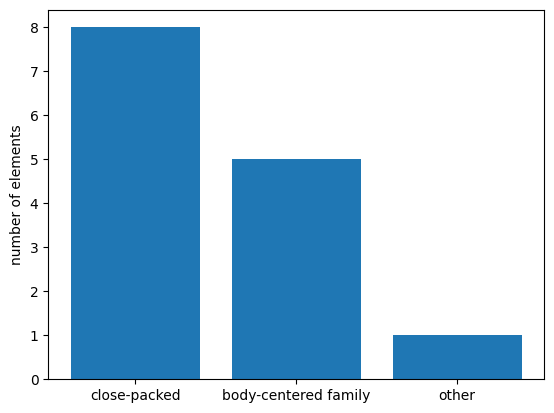

In [15]:
import matplotlib.pyplot as plt

category_counts = {}
for cat in categories:
    category_counts[cat] = category_counts.get(cat, 0) + 1

plt.bar(category_counts.keys(), category_counts.values())
plt.ylabel('number of elements')
plt.show()

### [Check your understanding]

* Loop over `data["Young's Modulus (GPa)"]`, build `stiffness_class`: `"soft"` (< 100 GPa), `"stiff"` (100-200), `"very stiff"` (> 200)
* Assign to `data['Stiffness Class']`
* Display `data[['Element', "Young's Modulus (GPa)", 'Stiffness Class']]`

Next time: Examples/Quiz 2 — today's loops and conditionals, recombined with Lecture 11's masks, under time pressure.